In [1]:
# Configuration OpenMP
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib
from torch.utils.data import Dataset, DataLoader, random_split

# Imports des modules locaux
from data_loading import *
from models import *
from training import *
from visualization import *
from evaluation import *

print("✓ Modules rechargés avec succès")

✓ Modules rechargés avec succès


### Env configuration

In [2]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {device}")

# Data path configuration
project_root = Path(os.getcwd()).parent  # go back from modular -> NFTM_for_Physic -> NFTM
data_dir = project_root / "Data"
print(f"Data directory: {data_dir}")

models_dir = project_root / "saved_models"

WINDOW_SIZE = 10

Device used: cpu
Data directory: c:\Users\alexa\Documents\MASTER PARIS SACLAY\COURSES\BDRP\ML_Differential_Solver\Data


### Dataset Configuration and Loading

In [3]:
MODEL = "TCAN" # change to "TRANSFORMER" to use other model
# MODEL = "TRANSFORMER" # change to "TCAN" to use other model

batch_size = 4
history_len = 3  # Only used for "generated" dataset

# Count samples per viscosity
def count_samples_per_nu(data_dir):
    npz_files = list(data_dir.glob("*.npz"))
    nu_counts = {}
    
    for path in npz_files:
        data = np.load(path)
        nu = float(data['nu'])
        nu_counts[nu] = nu_counts.get(nu, 0) + 1
    
    return sorted(nu_counts.items())

### New dataset

We will analyze a new dataset from benchmark: [repository](https://github.com/neuraloperator/neuraloperator.git)


ANALYZING RESOLUTION: 85X85
Shape of data tensor: torch.Size([85, 85])

TRAINING SET - Samples (85x85) per Viscosity
ν =     0.0005: 500 samples
ν =     0.0010: 500 samples
ν =     0.0040: 500 samples
ν =     0.0090: 500 samples
ν =     0.0100: 500 samples
ν =     0.0200: 500 samples
ν =     0.0600: 500 samples
ν =     0.1000: 500 samples
ν =     0.3000: 500 samples
ν =     0.5000: 500 samples
ν =     0.7000: 500 samples

TESTING SET - Samples (85x85) per Viscosity
ν =     0.0005:  77 samples
ν =     0.0010:  76 samples
ν =     0.0040:  78 samples
ν =     0.0090:  75 samples
ν =     0.0100:  70 samples
ν =     0.0200:  81 samples
ν =     0.0600:  76 samples
ν =     0.1000:  73 samples
ν =     0.3000:  71 samples
ν =     0.5000:  77 samples
ν =     0.7000:  76 samples

Total training samples (85x85): 5500
Total testing samples (85x85): 830
Train loader created with 5500 samples
Test loader created with 830 samples
Sample 3432 | nu=0.0600
 initial_field: torch.Size([85])
 trajectory   :

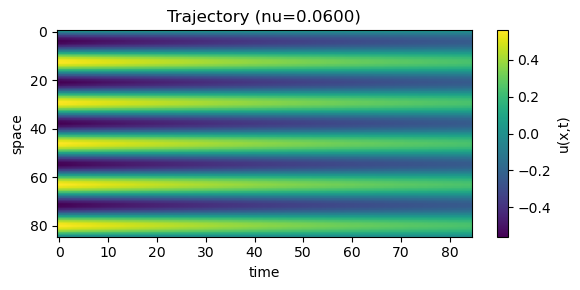


--------------------------------------------------------------------------------

ANALYZING RESOLUTION: 141X141
Shape of data tensor: torch.Size([141, 141])

TRAINING SET - Samples (141x141) per Viscosity
ν =     0.0005: 500 samples
ν =     0.0010: 500 samples
ν =     0.0040: 500 samples
ν =     0.0090: 500 samples
ν =     0.0100: 500 samples
ν =     0.0200: 500 samples
ν =     0.0600: 500 samples
ν =     0.1000: 500 samples
ν =     0.3000: 500 samples
ν =     0.5000: 500 samples
ν =     0.7000: 500 samples

TESTING SET - Samples (141x141) per Viscosity
ν =     0.0005:  51 samples
ν =     0.0010:  49 samples
ν =     0.0040:  49 samples
ν =     0.0090:  39 samples
ν =     0.0100:  53 samples
ν =     0.0200:  56 samples
ν =     0.0600:  58 samples
ν =     0.1000:  40 samples
ν =     0.3000:  48 samples
ν =     0.5000:  47 samples
ν =     0.7000:  48 samples

Total training samples (141x141): 5500
Total testing samples (141x141): 538
Train loader created with 5500 samples
Test loader cre

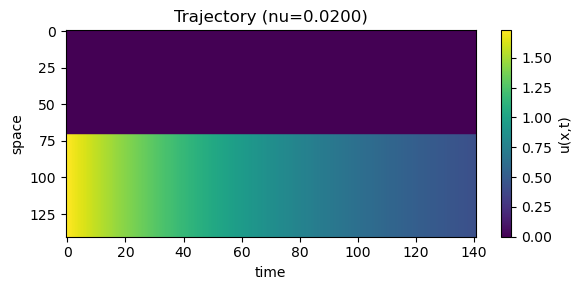


--------------------------------------------------------------------------------

ANALYZING RESOLUTION: 211X211
Shape of data tensor: torch.Size([211, 211])

TRAINING SET - Samples (211x211) per Viscosity
ν =     0.0005: 500 samples
ν =     0.0010: 500 samples
ν =     0.0040: 500 samples
ν =     0.0090: 500 samples
ν =     0.0100: 500 samples
ν =     0.0200: 500 samples
ν =     0.0600: 500 samples
ν =     0.1000: 500 samples
ν =     0.3000: 500 samples
ν =     0.5000: 500 samples
ν =     0.7000: 500 samples

TESTING SET - Samples (211x211) per Viscosity
ν =     0.0005:  54 samples
ν =     0.0010:  42 samples
ν =     0.0040:  49 samples
ν =     0.0090:  52 samples
ν =     0.0100:  50 samples
ν =     0.0200:  54 samples
ν =     0.0600:  48 samples
ν =     0.1000:  44 samples
ν =     0.3000:  50 samples
ν =     0.5000:  47 samples
ν =     0.7000:  54 samples

Total training samples (211x211): 5500
Total testing samples (211x211): 544
Train loader created with 5500 samples
Test loader cre

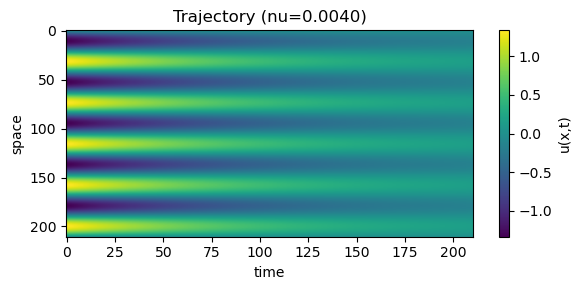


--------------------------------------------------------------------------------

ANALYZING RESOLUTION: 421X421
Shape of data tensor: torch.Size([421, 421])

TRAINING SET - Samples (421x421) per Viscosity
ν =     0.0005: 500 samples
ν =     0.0010: 500 samples
ν =     0.0040: 500 samples
ν =     0.0090: 500 samples
ν =     0.0100: 500 samples
ν =     0.0200: 500 samples
ν =     0.0600: 500 samples
ν =     0.1000: 500 samples
ν =     0.3000: 500 samples
ν =     0.5000: 500 samples
ν =     0.7000: 500 samples

TESTING SET - Samples (421x421) per Viscosity
ν =     0.0005:  56 samples
ν =     0.0010:  54 samples
ν =     0.0040:  50 samples
ν =     0.0090:  46 samples
ν =     0.0100:  57 samples
ν =     0.0200:  53 samples
ν =     0.0600:  53 samples
ν =     0.1000:  43 samples
ν =     0.3000:  52 samples
ν =     0.5000:  57 samples
ν =     0.7000:  40 samples

Total training samples (421x421): 5500
Total testing samples (421x421): 561
Train loader created with 5500 samples
Test loader cre

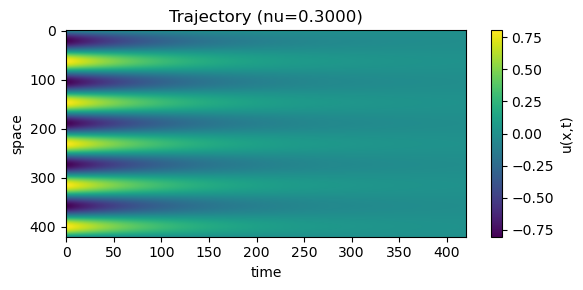


--------------------------------------------------------------------------------


In [ ]:
# resolutions = ['85x85', '141x141', '211x211', '421x421']
resolutions = ['85x85']
# resolutions = ['421x421']
train_loaders = []
test_loaders = []
for res in resolutions:
    print(f"\n{'='*80}")
    print(f"ANALYZING RESOLUTION: {res.upper()}")
    print(f"{'='*80}")
    
    # File paths for current resolution
    file_path_train = project_root / "saved_dataset" / f"burgers_data_{res}" / "train"
    file_path_test = project_root / "saved_dataset" / f"burgers_data_{res}" / "test"
    
    # List npz files
    npz_files_train = list(file_path_train.glob("*.npz"))
    npz_files_test = list(file_path_test.glob("*.npz"))
    
    # Analyze both splits
    train_counts = count_samples_per_nu(file_path_train)
    test_counts = count_samples_per_nu(file_path_test)
    
    nu_test = set()
    nu_train = set()
    
    for i, path in enumerate(npz_files_test):
        nu = float(np.load(path)['nu'])
        nu_test.add(nu)
    
    for i, path in enumerate(npz_files_train):
        data = np.load(path)['U']  # (100, T, N) - adjust key if needed
        nu = float(np.load(path)['nu'])
        nu_train.add(nu)
        
        x = np.load(path)['x']
        t = np.load(path)['t']
        
        if i == len(npz_files_train) - 1:  # Last file: print shapes
            data_t = torch.tensor(data, dtype=torch.float32)
            nu_t = torch.tensor(nu, dtype=torch.float32)
            x_t = torch.tensor(x, dtype=torch.float32)
            t_t = torch.tensor(t, dtype=torch.float32)
            print(f"Shape of data tensor: {data_t.shape}")
    
    # Create DataLoaders for this resolution
    train_loader, test_loader = create_generated_dataloaders_from_folders(
        train_dir=str(file_path_train),
        test_dir=str(file_path_test),
        history_len=history_len,
        batch_size=batch_size
    )

    train_loaders.append(train_loader)
    test_loaders.append(test_loader)
    
    print("\n" + "="*60)
    print(f"TRAINING SET - Samples ({res}) per Viscosity")
    print("="*60)
    for nu_val, count in train_counts:
        print(f"ν = {nu_val:10.4f}: {count:3d} samples")
    
    print("\n" + "="*60)
    print(f"TESTING SET - Samples ({res}) per Viscosity")
    print("="*60)
    for nu_val, count in test_counts:
        print(f"ν = {nu_val:10.4f}: {count:3d} samples")
    
    print(f"\nTotal training samples ({res}): {sum(count for _, count in train_counts)}")
    print(f"Total testing samples ({res}): {sum(count for _, count in test_counts)}")
    
    print(f"Train loader created with {len(train_loader.dataset)} samples")
    print(f"Test loader created with {len(test_loader.dataset)} samples")
    
    # Show sample
    dataset = train_loader.dataset
    init_field, true_traj, nu = dataset[0]
    if hasattr(dataset, 'dataset'):  # Handle random_split wrapper
        dataset = dataset.dataset
    idx = np.random.randint(0, len(dataset))
    show_random_sample(dataset, idx)
    
    print(f"\n{'-'*80}")  # Separator between resolutions


Sample 479 | nu=0.0600
 initial_field: torch.Size([421])
 trajectory   : torch.Size([421, 421])


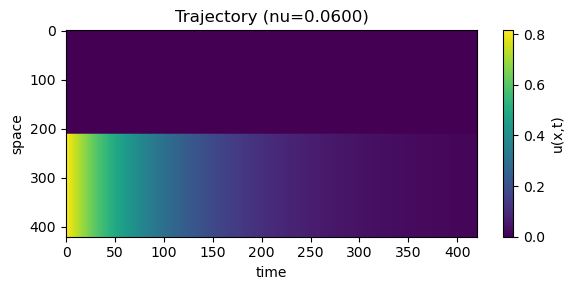

We consider 421 spatial positions per trajectory
We consider 421 time snapshots per trajectory


In [14]:
# For generated dataset, show sample from the training set
dataset = train_loader.dataset
init_field, true_traj, nu = dataset[0]
if hasattr(dataset, 'dataset'):  # Handle random_split wrapper
    dataset = dataset.dataset
idx = np.random.randint(0, len(dataset))
show_random_sample(dataset, idx)

T, N = true_traj.shape
print(f"We consider {N} spatial positions per trajectory")
print(f"We consider {T} time snapshots per trajectory")

### Model training

In [ ]:
# Model configuration
patch_radius = 1
patch_size = 2 * patch_radius + 1
chunk_size = 5
history_len = 20
num_epochs = 150


print(f"Starting training {MODEL} Controller for {num_epochs} epochs...")
print("=" * 60)

models = {}
if MODEL == "TCAN":
    for i, res in enumerate(resolutions):
        print(f"\n{'*'*80}")
        print(f"TRAINING TCAN MODEL FOR {res.upper()} RESOLUTION")
        print(f"{'*'*80}")
        
        train_loader = train_loaders[i]
        test_loader = test_loaders[i]

        model = ImprovedBurgersNet(window_size = history_len, corr_clip = 0.4, use_viscosity=True).to(device)
        # Train
        model, history, history_len = train_model_TCAN(train_loader, test_loader, history_len, num_epochs, resolution=res, model = model)

        # save model
        model_name = f"TCAN_Controller_{res}.pth"
        model_path = models_dir / model_name
        torch.save(model, model_path)
        print(f"Model saved as: {model_path}")

        models[res] = {'model': model, 'history': history, 'path': model_path}

    # train_losses = history.get("loss", [])
    # training_mode = "TCAN Controller"

elif MODEL == "TRANSFORMER":
    for i, res in enumerate(resolutions):
        print(f"\n{'*'*80}")
        print(f"TRAINING TRANSFORMER MODEL FOR {res.upper()} RESOLUTION")
        print(f"{'*'*80}")
        
        train_loader = train_loaders[i]
        test_loader = test_loaders[i]

        model = TransformerController(patch_size=patch_size).to(device)
        # Train transformer/RNN variant
        model, train_losses = train_rnn_patch(
            model=model,
            dataloader=train_loader,
            device=device,
            patch_radius=patch_radius,
            num_epochs=num_epochs,
            chunk_size=chunk_size,   # utilisé seulement pour les modèles séquentiels
        )

        # save model
        model_name = f"TRANSFORMER_Controller_{res}.pth"
        model_path = models_dir / model_name
        torch.save(model, model_path)
        print(f"Model saved as: {model_path}")

        models[res] = {'model': model, 'train_losses': train_losses, 'path': model_path}

    # training_mode = "RNN Patch"
else:
    raise ValueError(f"Unknown MODEL={MODEL}")

### Load model

In [ ]:
# LOAD_MODEL_NAME = None

# if MODEL == "TRANSFORMER":
#     # --- Load a saved model # 
#     # LOAD_MODEL_NAME = "transformers.pth"  # Set to filename like "my_model.pth" to load a model

#     # if LOAD_MODEL_NAME is not None:
#     #     print(f"📥 Loading model from: {LOAD_MODEL_NAME}")
#     #     model = torch.load(models_dir / LOAD_MODEL_NAME, map_location=device, weights_only=False)
#     #     print(f"✓ Model loaded successfully")

#     # model = model.to(device)

#     # print(f"Model information:")
#     # print(f"  - Patch radius: {patch_radius}")
#     # print(f"  - Patch size: {patch_size}")
#     # print(f"  - Number of parameters: {sum(p.numel() for p in model.parameters())}")
#     # print(f"\nModel architecture:")
#     # print(model)
#     models = {}
#     for i, res in enumerate(resolutions):
#         LOAD_MODEL_NAME = f"TRANSFORMER_Controller_{res}.pth"
#         model = torch.load(models_dir / LOAD_MODEL_NAME, map_location=device, weights_only=False)
#         models[res] = model
#         print(f"Loaded TRANSFORMER model for resolution {res} from: {LOAD_MODEL_NAME}")

# if MODEL == "TCAN":
#     models = {}
#     for i, res in enumerate(resolutions):
#         LOAD_MODEL_NAME = f"TCAN_Controller_{res}.pth"
#         model = torch.load(models_dir / LOAD_MODEL_NAME, map_location=device, weights_only=False)
#         models[res] = model
#         print(f"Loaded TCAN model for resolution {res} from: {LOAD_MODEL_NAME}")


Loaded TCAN model for resolution 85x85 from: TCAN_Controller_85x85.pth
Loaded TCAN model for resolution 141x141 from: TCAN_Controller_141x141.pth
Loaded TCAN model for resolution 211x211 from: TCAN_Controller_211x211.pth
Loaded TCAN model for resolution 421x421 from: TCAN_Controller_421x421.pth


### Loss funciton

In [10]:
# plot_losses(train_losses)

# print(f"Final loss: {train_losses[-1]:.6f}")
# print(f"Loss reduction: {((train_losses[0] - train_losses[-1])/train_losses[0]*100):.2f}%")

## Visualization

In [11]:
# # Choose a single nu target to use for both visualization and evaluation
# # Supported values: float (e.g. 0.01), 'min', 'max', 'idx:N', 'random', 'list', or None
# PLOT_NU = 'random'  # change this value to pick a specific sample or 'list' for available nus

# # Resolve selected_nu once and store it globally
# eval_loader = test_loader if test_loader is not None else train_loader
# loader_type = "test" if test_loader is not None else "train"

# print(f"🎯 Resolving nu target using loader: {loader_type} and PLOT_NU={PLOT_NU}")
# selected_nu = resolve_nu_target(eval_loader, plot_nu=PLOT_NU, selected_nu=None, list_nus=True, verbose=True)

# if selected_nu is None:
#     print("No specific nu selected; visualization/evaluation will use default (first sample from loader).")
# else:
#     print(f"Global selected_nu set: {selected_nu}")


In [12]:
# Generate predictions for visualization
# Use test_loader if available, otherwise fall back to train_loader

# Use the selected_nu set by the single selection cell above if present
# selected_nu_local = globals().get('selected_nu', None)

# eval_loader = test_loader if test_loader is not None else train_loader
# loader_type = "test" if test_loader is not None else "train"

# print(f"🔍 Generating predictions using {loader_type} data...")

# if selected_nu_local is None:
#     print("No global selected_nu set; the first sample from the loader will be used for visualization (nu_target=None).")
# else:
#     print(f"Using selected nu target for visualization: {selected_nu_local}")

# true_traj, pred_traj, nu_value = generate_model_predictions(
#     model, 
#     eval_loader, 
#     device, 
#     patch_radius, 
#     verbose=True, 
#     chunk_size=chunk_size,
#     nu_target=selected_nu_local,
#     list_nus=False,
#     fallback_to_first=True,
# )

# # Visualize trajectories
# plot_trajectories(true_traj, pred_traj, title_suffix=f" (nu={nu_value:.4f}, {loader_type} data)")


## Evaluation

In [13]:
# # Complete evaluation with dedicated function
# # Use test_loader if available, otherwise fall back to train_loader
# eval_loader = test_loader if test_loader is not None else train_loader
# loader_type = "test" if test_loader is not None else "train"

# print(f"📊 Evaluating model performance on {loader_type} data...")

# # Use the same selected nu set by the single selection cell (selected_nu)
# selected_nu_local = globals().get('selected_nu', None)

# # Do not call resolve_nu_target here - central selection is in the single cell
# if selected_nu_local is None:
#     eval_nu_target = None
#     print("No global selected_nu set for evaluation; using default (first sample from loader).")
# else:
#     eval_nu_target = selected_nu_local
#     print(f"Using selected nu target for evaluation: {eval_nu_target}")

# evaluation_results = evaluate_model_on_sample(
#     model,
#     eval_loader,
#     device,
#     patch_radius,
#     max_val=1.0,
#     val_range=1.0,
#     chunk_size=chunk_size,
#     nu_target=eval_nu_target,
# )

# # Display results with dedicated function
# true_traj, pred_traj = display_evaluation_results(evaluation_results, show_plots=True)


In [14]:
# if test_loader is not None:
#     mean_error_per_time = error_evolution_on_loader(
#         model,
#         test_loader,
#         device,
#         patch_radius=patch_radius,
#         chunk_size=chunk_size,
#         show_plot=True,   # met à False si tu veux juste les valeurs
#         metric="rel_l2"
#     )
#     print(f"Mean error_per_time shape: {mean_error_per_time.shape}")
    
#     # Calcul de l'erreur L2 moyenne globale
#     mean_l2_error = np.mean(mean_error_per_time)
#     print(f"\n📊 Relative L2 Error (averaged over test set):")
#     print(f"   Global mean error: {mean_l2_error:.6f}")
#     print(f"   Min error (at any time): {np.min(mean_error_per_time):.6f}")
#     print(f"   Max error (at any time): {np.max(mean_error_per_time):.6f}")
# else:
#     print("No test loader available; skipping test set evaluation.")

### Comparison with table in the paper

For this, we compute the relative L2 error: $$RE_{L2} = \frac{||u_{pred} - u_{true}||_{L2}}{||u_{true}||_{L2}}$$

In [ ]:
# def relative_l2_error(pred, true):
#     diff_norms = torch.norm(pred.reshape(pred.shape[0], -1) - true.reshape(true.shape[0], -1), p=2, dim=1)
#     true_norms = torch.norm(true.reshape(true.shape[0], -1), p=2, dim=1)
#     return torch.mean(diff_norms / true_norms).item()

# # Create results directory
# results_dir = Path("..") / "saved_results" / "new_dataset_results" / MODEL  # "TCAN" or "TRANSFORMER"
# results_dir.mkdir(parents=True, exist_ok=True)
# print(f"Results will be saved to: {results_dir}")

# # Comparing Relative L2 Error across resolutions for TCAN and TRANSFORMER
# mean_rel_l2_error_per_resolution = {}
# error_evolution_per_resolution = {}  # Para guardar la evolución temporal

# if MODEL == "TCAN" and len(models) > 1:
#     for i, res in enumerate(resolutions):
#         print(f"\n{'='*80}")
#         print(f"Evaluating TCAN Relative L2 Error for resolution: {res.upper()}")
#         print(f"{'='*80}")
    
#         model = models[res]
#         test_loader = test_loaders[i]
        
#         # Collect all predictions and ground truths
#         all_rel_errors = []
#         all_timestep_errors = []  # Para cada timestep
        
#         model.eval()
#         with torch.no_grad():
#             for batch_idx, batch in enumerate(test_loader):
#                 init_field, true_traj, nu = batch
#                 init_field = init_field.to(device)
#                 true_traj = true_traj.to(device)
#                 nu = nu.to(device)
                

#                 window_size = history_len
#                 batch_size = init_field.shape[0]
#                 num_timesteps = true_traj.shape[1]

#                 u_history = init_field.unsqueeze(1).repeat(1, window_size, 1)
                
#                 pred_frames = []

#                 for t in range(num_timesteps):
#                     u_next = model(u_history)
#                     pred_frames.append(u_next)
#                     u_history = torch.cat([u_history[:, 1:, :], u_next], dim=1)
                
                
#                 # Get full prediction trajectory
#                 pred_traj = torch.cat(pred_frames, dim = 1)
                
#                 # Calculate relative L2 error at FINAL timestep
#                 rel_error_final = relative_l2_error(pred_traj[:, -1], true_traj[:, -1])
#                 all_rel_errors.append(rel_error_final)
                
#                 # Calculate relative L2 error at EACH timestep (for plotting evolution)
#                 timestep_errors = []
#                 for t in range(pred_traj.shape[1]):
#                     rel_error_t = relative_l2_error(pred_traj[:, t], true_traj[:, t])
#                     timestep_errors.append(rel_error_t)
#                 all_timestep_errors.append(timestep_errors)
        
#         # Mean relative L2 error across all test samples (final timestep)
#         mean_rel_l2 = np.mean(all_rel_errors)
#         mean_rel_l2_error_per_resolution[res] = mean_rel_l2
        
#         # Mean error evolution across timesteps
#         mean_error_evolution = np.mean(all_timestep_errors, axis=0)
#         error_evolution_per_resolution[res] = mean_error_evolution
        
#         print(f"Mean Relative L2 Error for {res}: {mean_rel_l2:.6f}")
        
#         # ========== PLOT: Error Evolution for this Resolution ==========
#         plt.figure(figsize=(10, 6))
#         timesteps = np.arange(len(mean_error_evolution))
#         plt.plot(timesteps, mean_error_evolution, 'o-', linewidth=2, markersize=4)
#         plt.xlabel('Time Step', fontsize=12)
#         plt.ylabel('Relative L2 Error', fontsize=12)
#         plt.title(f'{MODEL} - Error Evolution (Resolution {res})', fontsize=14)
#         plt.grid(True, alpha=0.3)
#         plt.tight_layout()
        
#         # Save plot for this resolution
#         plot_path = results_dir / f"error_evolution_{res}.png"
#         plt.savefig(plot_path, dpi=300, bbox_inches='tight')
#         print(f"✓ Plot saved to: {plot_path}")
#         plt.close()

# elif MODEL == "TRANSFORMER" and len(models) > 1:
#     for res_idx, res in enumerate(resolutions):
#         print(f"\n{'='*80}")
#         print(f"Evaluating TRANSFORMER Relative L2 Error for resolution: {res.upper()}")
#         print(f"{'='*80}")
        
#         model = models[res]
#         test_loader = test_loaders[res_idx]
        
#         # Collect all predictions and ground truths
#         all_rel_errors = []
#         all_timestep_errors = []
        
#         model.eval()
#         with torch.no_grad():
#             for batch_idx, batch in enumerate(test_loader):
#                 init_field, true_traj, nu = batch
#                 true_traj = true_traj.to(device)  # (B, T, N)
#                 nu = nu.to(device)                # (B, 1)
                
#                 B, T, N = true_traj.shape
                
#                 # Inicializar historial con primeros chunk_size frames
#                 # (o repetir init_field si no tenemos suficientes)
#                 if chunk_size <= T:
#                     current_chunk = true_traj[:, :chunk_size, :]  # (B, chunk_size, N)
#                 else:
#                     # Repetir init_field si chunk_size > frames disponibles
#                     init_field = init_field.to(device)
#                     current_chunk = init_field.unsqueeze(1).repeat(1, chunk_size, 1)
                
#                 # Autoregressive prediction
#                 pred_frames = []
                
#                 for t in range(T - chunk_size):
#                     # Build patches from current chunk
#                     patches = build_patches_from_sequence(current_chunk, patch_radius, patch_size)
#                     # patches: (B*N, chunk_size, P)
                    
#                     nu_expanded = nu.unsqueeze(1).expand(-1, N, -1).reshape(B * N, 1)
#                     pred_next = model(patches, nu_expanded).reshape(B, N)  # (B, N)
                    
#                     pred_frames.append(pred_next.unsqueeze(1))  # (B, 1, N)
                    
#                     # Update chunk: remove oldest, add newest prediction
#                     current_chunk = torch.cat([current_chunk[:, 1:, :], 
#                                               pred_next.unsqueeze(1)], dim=1)
                
#                 # Stack all predictions
#                 pred_traj = torch.cat(pred_frames, dim=1)  # (B, T-chunk_size, N)
#                 target_traj = true_traj[:, chunk_size:, :]  # (B, T-chunk_size, N)
                
#                 # Calculate relative L2 error at FINAL timestep
#                 rel_error_final = relative_l2_error(pred_traj[:, -1], target_traj[:, -1])
#                 all_rel_errors.append(rel_error_final)
                
#                 # Calculate relative L2 error at EACH timestep
#                 timestep_errors = []
#                 for t in range(pred_traj.shape[1]):
#                     rel_error_t = relative_l2_error(pred_traj[:, t], target_traj[:, t])
#                     timestep_errors.append(rel_error_t)
#                 all_timestep_errors.append(timestep_errors)
        
#         # Mean relative L2 error across all test samples
#         mean_rel_l2 = np.mean(all_rel_errors)
#         mean_rel_l2_error_per_resolution[res] = mean_rel_l2
        
#         # Mean error evolution across timesteps
#         mean_error_evolution = np.mean(all_timestep_errors, axis=0)
#         error_evolution_per_resolution[res] = mean_error_evolution
        
#         print(f"Mean Relative L2 Error for {res}: {mean_rel_l2:.6f}")
        
#         # ========== PLOT: Error Evolution for this Resolution ==========
#         plt.figure(figsize=(10, 6))
#         timesteps = np.arange(len(mean_error_evolution))
#         plt.plot(timesteps, mean_error_evolution, 'o-', linewidth=2, markersize=4)
#         plt.xlabel('Time Step', fontsize=12)
#         plt.ylabel('Relative L2 Error', fontsize=12)
#         plt.title(f'{MODEL} - Error Evolution (Resolution {res})', fontsize=14)
#         plt.grid(True, alpha=0.3)
#         plt.tight_layout()
        
#         # Save plot for this resolution
#         plot_path = results_dir / f"error_evolution_{res}.png"
#         plt.savefig(plot_path, dpi=300, bbox_inches='tight')
#         print(f"✓ Plot saved to: {plot_path}")
#         plt.close()

# # ========== PLOT: All Resolutions Together ==========
# if len(error_evolution_per_resolution) > 0:
#     plt.figure(figsize=(12, 7))
    
#     for res in resolutions:
#         if res in error_evolution_per_resolution:
#             error_evolution = error_evolution_per_resolution[res]
#             timesteps = np.arange(len(error_evolution))
#             plt.plot(timesteps, error_evolution, 'o-', linewidth=2, 
#                     markersize=3, label=f'Resolution {res}')
    
#     plt.xlabel('Time Step', fontsize=12)
#     plt.ylabel('Relative L2 Error', fontsize=12)
#     plt.title(f'{MODEL} - Error Evolution Across All Resolutions', fontsize=14)
#     plt.legend(fontsize=10)
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
    
#     # Save combined plot
#     combined_plot_path = results_dir / "error_evolution_all_resolutions.png"
#     plt.savefig(combined_plot_path, dpi=300, bbox_inches='tight')
#     print(f"\n✓ Combined plot saved to: {combined_plot_path}")
#     plt.close()


# # ========== COMPARISON TABLE (FNO paper style) ==========
# print(f"\n{'='*60}")
# print("COMPARISON WITH FNO PAPER - Burgers Equation (1)")
# print(f"{'='*60}")

# # FNO paper results for reference
# fno_results = {
#     "85x85": 0.0108,
#     "141x141": 0.0109,
#     "211x211": 0.0109,
#     "421x421": 0.0098
# }

# print("\n| Model       | s=85    | s=141   | s=211   | s=421   |")
# print("|-------------|---------|---------|---------|---------|")

# # FNO baseline
# print(f"| FNO         | {fno_results['85x85']:.4f}  | {fno_results['141x141']:.4f}  | {fno_results['211x211']:.4f}  | {fno_results['421x421']:.4f}  |")

# # Your model results
# model_name = "TCAN" if MODEL == "TCAN" else "TRANSFORMER"
# print(f"| {model_name:<11} |", end="")
# for res in ["85x85", "141x141", "211x211", "421x421"]:
#     if res in mean_rel_l2_error_per_resolution:
#         error = mean_rel_l2_error_per_resolution[res]
#         print(f" {error:.4f}  |", end="")
#     else:
#         print(f" {'N/A':<7} |", end="")
# print()

# print(f"{'='*60}\n")

# # Detailed breakdown
# print("\n" + "="*60)
# print(f"{model_name} - RELATIVE L2 ERROR BY RESOLUTION")
# print("="*60)
# print("| Resolution | Rel L2 Error |")
# print("|------------|--------------|")
# for res in resolutions:
#     if res in mean_rel_l2_error_per_resolution:
#         rel_l2 = mean_rel_l2_error_per_resolution[res]
#         print(f"| {res:>10} | {rel_l2:>12.6f} |")
# print("="*60)

# # ========== SAVE TABLE TO FILE ==========
# table_path = results_dir / "comparison_table.txt"
# with open(table_path, 'w') as f:
#     f.write("="*60 + "\n")
#     f.write("COMPARISON WITH FNO PAPER - Burgers Equation (1)\n")
#     f.write("="*60 + "\n\n")
    
#     f.write("| Model       | s=85    | s=141   | s=211   | s=421   |\n")
#     f.write("|-------------|---------|---------|---------|---------|" + "\n")
    
#     # FNO baseline
#     f.write(f"| FNO         | {fno_results['85x85']:.4f}  | {fno_results['141x141']:.4f}  | {fno_results['211x211']:.4f}  | {fno_results['421x421']:.4f}  |\n")
    
#     # Your model
#     f.write(f"| {model_name:<11} |")
#     for res in ["85x85", "141x141", "211x211", "421x421"]:
#         if res in mean_rel_l2_error_per_resolution:
#             error = mean_rel_l2_error_per_resolution[res]
#             f.write(f" {error:.4f}  |")
#         else:
#             f.write(f" {'N/A':<7} |")
#     f.write("\n")
    
#     f.write("="*60 + "\n")

# print(f"\n✓ Comparison table saved to: {table_path}")

# # ========== SAVE RAW DATA ==========
# import json

# data_path = results_dir / "rel_l2_errors.json"
# data_to_save = {
#     "model": MODEL,
#     "final_errors": mean_rel_l2_error_per_resolution,
#     "error_evolution": {k: v.tolist() for k, v in error_evolution_per_resolution.items()},
#     "fno_baseline": fno_results
# }

# with open(data_path, 'w') as f:
#     json.dump(data_to_save, f, indent=2)

# print(f"Raw data saved to: {data_path}")


Results will be saved to: saved_results\new_dataset_results\TCAN

Evaluating TCAN Relative L2 Error for resolution: 85X85
Mean Relative L2 Error for 85x85: 0.031113
✓ Plot saved to: saved_results\new_dataset_results\TCAN\error_evolution_85x85.png

Evaluating TCAN Relative L2 Error for resolution: 141X141
Mean Relative L2 Error for 141x141: 0.188314
✓ Plot saved to: saved_results\new_dataset_results\TCAN\error_evolution_141x141.png

Evaluating TCAN Relative L2 Error for resolution: 211X211
Mean Relative L2 Error for 211x211: 0.379374
✓ Plot saved to: saved_results\new_dataset_results\TCAN\error_evolution_211x211.png

Evaluating TCAN Relative L2 Error for resolution: 421X421
Mean Relative L2 Error for 421x421: 6.008358
✓ Plot saved to: saved_results\new_dataset_results\TCAN\error_evolution_421x421.png

✓ Combined plot saved to: saved_results\new_dataset_results\TCAN\error_evolution_all_resolutions.png

COMPARISON WITH FNO PAPER - Burgers Equation (1)

| Model       | s=85    | s=141   | 

### Save Model

In [ ]:
# ========== MODEL SAVING ==========
# SAVE_MODEL_NAME = "transformers.pth"  

# if SAVE_MODEL_NAME is not None:
#     print(f"💾 Saving model to: {SAVE_MODEL_NAME}")
#     torch.save(model, models_dir / SAVE_MODEL_NAME)
#     print(f"✓ Model saved successfully to: {models_dir / SAVE_MODEL_NAME}")
# else:
#     print("ℹ️  To save the model, set SAVE_MODEL_NAME = 'filename.pth'")
#     print(f"   Models will be saved to: {models_dir}")

💾 Saving model to: transformers.pth
✓ Model saved successfully to: c:\Dev\CentralSupelec\BDRP\ML_Differential_Solver\saved_models\transformers.pth


In [ ]:
# # 🔎 Debug: display unique nu values in train/test loaders
# try:
#     if 'test_loader' in globals() and test_loader is not None:
#         print("Test loader unique nu values:", get_loader_nu_values(test_loader))
#     if 'train_loader' in globals() and train_loader is not None:
#         print("Train loader unique nu values:", get_loader_nu_values(train_loader))
# except Exception as e:
#     print("Unable to inspect loader nus:", e)

Test loader unique nu values: [0.009999999776482582, 0.026896551251411438, 0.04379310458898544, 0.06068965420126915, 0.07758620381355286, 0.09448275715112686, 0.11137931048870087, 0.12827585637569427, 0.14517241716384888, 0.16206896305084229, 0.1789655238389969, 0.1958620697259903, 0.2127586156129837, 0.2296551764011383, 0.2465517222881317, 0.2634482681751251, 0.28034481406211853, 0.2972413897514343, 0.31413793563842773, 0.33103448152542114, 0.34793102741241455, 0.36482757329940796, 0.38172414898872375, 0.39862069487571716, 0.41551724076271057, 0.432413786649704, 0.4493103325366974, 0.4662069082260132, 0.4831034541130066, 0.5]
Train loader unique nu values: [0.009999999776482582, 0.026896551251411438, 0.04379310458898544, 0.06068965420126915, 0.07758620381355286, 0.09448275715112686, 0.11137931048870087, 0.12827585637569427, 0.14517241716384888, 0.16206896305084229, 0.1789655238389969, 0.1958620697259903, 0.2127586156129837, 0.2296551764011383, 0.2465517222881317, 0.2634482681751251, 0